# Introducción
La base de datos [Chinook](https://github.com/lerocha/chinook-database?tab=readme-ov-file) representa una tienda virtual de música. Incluyendo tablas para artistas, álbumes, pistas, facturas y clientes. 
Queremos buscar patrones ---ya sea entre columnas en la misma tabla o entre columnas en distintas tablas--- que ayuden, de forma general, a mejorar los procesos
en la tienda. Seguiremos el proceso estándar, aunque reducido, del análisis de datos: exploración, limpieza, modelado y visualización. Es necesario recordar que el proceso
de análisis de datos no es lineal, regresamos sobre nuestros pasos, iteramos o tomamos otro camino; pero siempre seguimos el camino que nos indican los datos.

La imagen de abajo muestra la relaciones entre las tablas de la base de datos _Chinook_.

![table relationships](./img/chinook_tables.png)

Guiaremos nuestro análisis con las siguientes preguntas:
- ¿Cuál es la duración promedio de las canciones por género?
- ¿Cuál es el promedio de la compra por día?
- ¿Existe alguna relación entre el tamaño del archivo (Bytes) y el precio?


# Setup
Importamos los paquetes que usaremos y creamos la conexión a la base de datos. Por último listamos todas las tablas.

In [1]:
import pandas as pd
import numpy as np
import sqlite3 as sq
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Duración promedio de las canciones por género

In [2]:
conn = sq.connect('chinook.sqlite')
# Todas las tablas
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
tables

,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack


# Análisis Exploratorio 

In [74]:
pd.read_sql_query("SELECT * FROM MediaType", conn)

,MediaTypeId,Name
0,1,MPEG audio file
1,2,Protected AAC audio file
2,3,Protected MPEG-4 video file
3,4,Purchased AAC audio file
4,5,AAC audio file


In [51]:
duracion_genero = pd.read_sql_query("""
SELECT 
    genre.Name AS genero, 
    track.Milliseconds/1000 AS duracion 
FROM Track AS track
JOIN Genre AS genre ON track.GenreId = genre.GenreId
WHERE track.MediaTypeId != 3
;
""", conn)

box_duracion_genero = px.box(duracion_genero, x="genero", y="duracion", color="genero")
box_duracion_genero.show()

Vemos que géneros como Rock, Jazz, Metal y Latin tienen canciones con duraciones distintas, con muchos outliers. Mientras que géneros como Opera y Classical tienen una duración estándar, las canciones de esos géneros suelen tener duraciones similares.
En este punto, nos preguntamos si podemos predecir el género basándonos en la duración de la canción. Todavía más, ¿Existe alguna relación entre el género y un conjunto de columnas en las tablas? Digamos:
$$Genre = Milliseconds + Bytes + UnitPrice$$
Hacemos un ejercicio similar con las variables restantes.

In [52]:
genero_bytes = pd.read_sql_query("""
SELECT 
    genre.Name AS genero, 
    track.Bytes AS tamano
FROM Track AS track
JOIN Genre AS genre ON track.GenreId = genre.GenreId
WHERE track.MediaTypeId != 3
;
""", conn)

box_genero_bytes = px.box(genero_bytes, x="genero", y="tamano", color="genero")
box_genero_bytes.show()

Al intentar hacer lo mismo con el precio, encontramos algo interesante: todas las canciones tienen el mismo precio. Por lo tanto, no hay relación posible entre género y precio unitario.

In [ ]:
genero_price = pd.read_sql_query("""
SELECT 
    genre.Name AS genero, 
    track.UnitPrice AS precio 
FROM Track AS track
JOIN Genre AS genre ON track.GenreId = genre.GenreId
WHERE track.MediaTypeId != 3
;
""", conn)

graph_genero_price = px.line(genero_price, x="genero", y="precio")
graph_genero_price.show()

In [7]:
data = pd.read_sql_query(
"""
SELECT 
    genre.Name AS genero, 
    track.Bytes AS tamano,
    track.Milliseconds AS duracion,
    track.MediaTypeId as tipo
FROM Track AS track
JOIN Genre AS genre ON track.GenreId = genre.GenreId
WHERE track.MediaTypeId != 3
;
""", conn)

graph_genero_tam_dur = px.scatter(data, x="tamano", y="duracion", color="genero")
graph_genero_tam_dur.show()

Ya que los datos se encuentran muy juntos, usamos PCA para separalos (maximizar la dispersión). Por el número de variables, no podemos esperar reducir la dimensión pero si una rotación de los datos en la
dirección de varianza máxima. Si dicha separación por géneros existe, será más visible en la proyección lineal dada por PCA.

In [20]:
# 1. Prepare your data (X must be numeric)
X = data.drop('genero', axis=1) 
# 2. Standardize the features (Mean=0, Variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA
# You can specify the number of components, e.g., n_components=2
pca = PCA(n_components=None) 
pca_data = pca.fit_transform(X_scaled)

# 4. Convert to a readable DataFrame
df_pca = pd.DataFrame(pca_data, columns=[f'PC{i+1}' for i in range(pca_data.shape[1])])

Los primeros dos componentes principales explican ~99% de la dispersión en los datos, entonces solamente conservamos los primeros dos componentes principales.

In [15]:
print(pca.explained_variance_ratio_)

[0.64233772 0.33790931 0.01975297]


In [98]:
graph_pca = px.scatter(df_pca, x="PC1", y="PC2", color=data["genero"])
graph_pca.show()

In [ ]:
No parece haber relación entre el género y duración y tamaño. Si existe, no es lineal.

Veámos los que pasa si graficamos ahora intentamos el modelo
$$tipo = duracion + tamano$$
En los datos originales y coloreando por género.

In [11]:
fig2 = px.scatter_3d(data, x="duracion", y="tamano", z="tipo", color="genero")
fig2.show()

In [14]:
graph_pca = px.scatter(df_pca, x="PC1", y="PC2", color=data["tipo"])
graph_pca.show()

Claramente se forman cuatro grupos correspondientes a cada tipo de archivo. De manera un poco más formal, esto significa que los datos yacen, ya sea en una _variedad lineal_ o en una _variedad no-lineal_ que puede aproximarse por un espacio lineal. En términos accionables, esto nos dá evidencia a favor del modelo
$$tipo = genero + duracion + tamano$$
Esto responde nuestra primera pregunta guía: parece haber relación entre el género y tipo, tamaño y duración de las canciones pero si parece haberla entre el tipo en función del género, tamaño y tipo de archivo. Podemos tomar distintos caminos a partir de aquí. Usando regresión, podemos modelar la relación $tipo = genero + duracion + tamano$ ; otro camino, aunque menos interesante, es clasificar nuevas canciones ---de las que no sabemos el tipo de archivo--- solamente sabiendo su género, tamaño y duración. Nosotros terminamos aquí el anállisis.

# Promedio de Compras por día

La consulta para obtener la información que deseamos es la siguiente.

In [143]:
promedio_dia = pd.read_sql_query("""
SELECT DATE(InvoiceDate) as fecha, AVG(Total) as promedio FROM Invoice AS inv
GROUP BY fecha 
ORDER BY fecha ASC
;""", conn)

fig3 = px.line(promedio_dia, x="fecha", y="promedio")
fig3.show()

Es interesante que está consulta arroja una serie de tiempo. Nuestro objetivo será predecir las ventas en los siguientes días por dos vías: un modelo $ARIMA(p, d, q)$ usando la metodología Box-Jenkins y un modelo $SARIMA(p, d, q)(P, D, Q)$ usando la función `auto arima`.
Empezamos por importar las librerías y preparar los datos.

In [147]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

promedio_dia['fecha'] = pd.to_datetime(promedio_dia['fecha'])
promedio_dia.set_index('fecha', inplace=True)

La prueba ADF, confirma que la serie es estacionaria con lo que tenemos el primer parámetro del modelo $d = 0$.

In [30]:
adf = adfuller(promedio_dia)
print(f"La series es estacionaria: p-value: {adf[1]}")

La series es estacionaria: p-value: 0.0031171215481076062


Para encontrar los parámero restantes usamos los correlogramas.

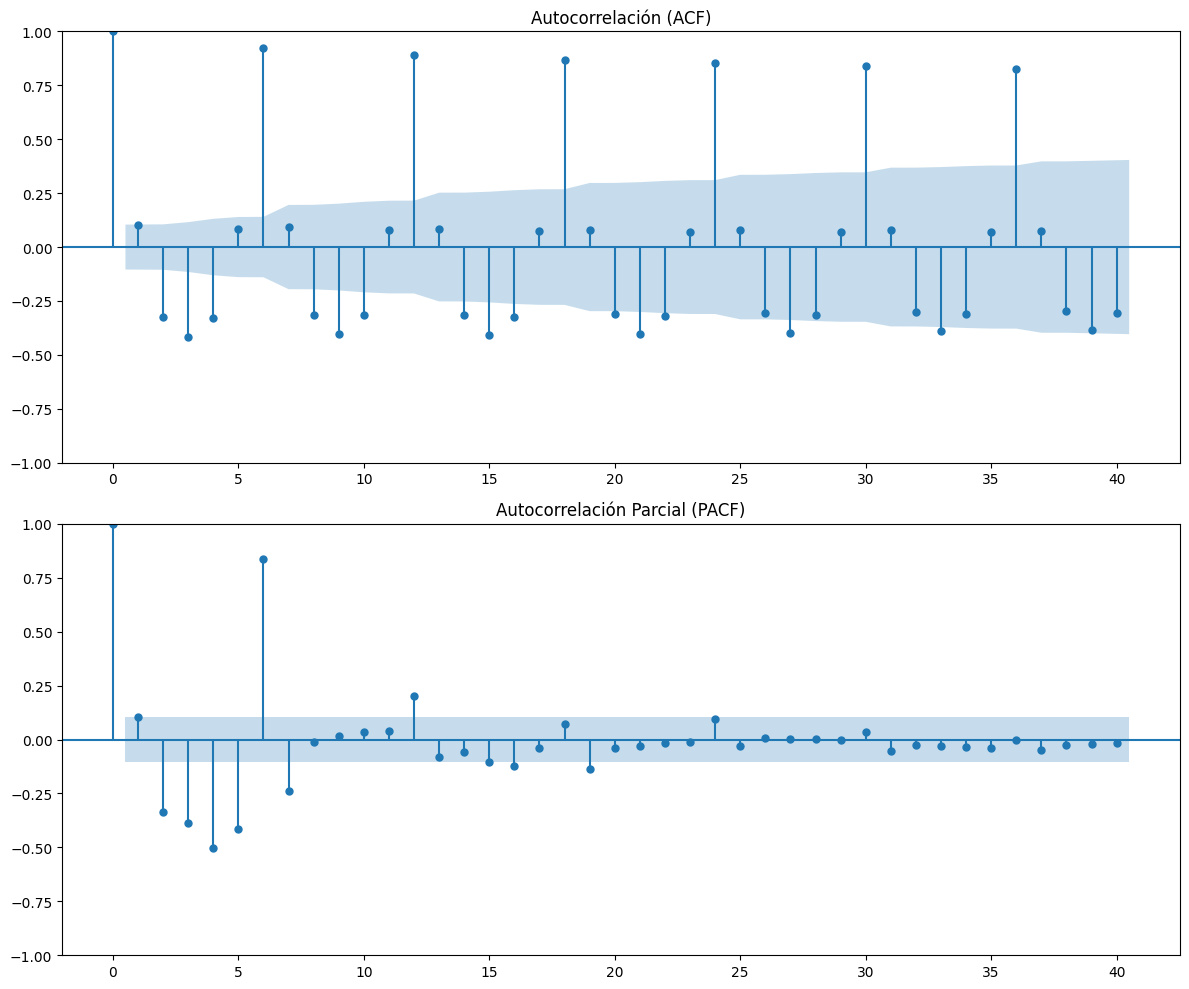

In [31]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF
plot_acf(promedio_dia, lags=40, ax=ax1, title="Autocorrelación (ACF)")

# PACF
plot_pacf(promedio_dia, lags=40, ax=ax2, title="Autocorrelación Parcial (PACF)")

plt.tight_layout()
plt.show()

Como tanto ACF como PACF se cortan, $p = q = 1$. Así, el modelo es $ARIMA(1, 0, 1)$.

In [ ]:
model = ARIMA(promedio_dia, order=(1, 0, 1)) 
model_fit = model.fit()

print(model_fit.summary())

# Forecast 
forecast = model_fit.get_forecast(steps=30, alpha=0.05)
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()
print(f"Forecasted values: {forecast}")

                               SARIMAX Results                                
Dep. Variable:               promedio   No. Observations:                  354
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1044.067
Date:                Sun, 19 Apr 2026   AIC                           2096.133
Time:                        17:09:00   BIC                           2111.611
Sample:                             0   HQIC                          2102.291
                                - 354                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.2394      0.146     42.775      0.000       5.953       6.525
ar.L1          0.5428      0.118      4.617      0.000       0.312       0.773
ma.L1         -0.8210      0.065    -12.712      0.0

/home/akatl/Lambda/dataAnalysisVenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/akatl/Lambda/dataAnalysisVenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/akatl/Lambda/dataAnalysisVenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/akatl/Lambda/dataAnalysisVenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will 

In [161]:
promedio_dia.index.tolist()

[Timestamp('2009-01-01 00:00:00'),
 Timestamp('2009-01-02 00:00:00'),
 Timestamp('2009-01-03 00:00:00'),
 Timestamp('2009-01-06 00:00:00'),
 Timestamp('2009-01-11 00:00:00'),
 Timestamp('2009-01-19 00:00:00'),
 Timestamp('2009-02-01 00:00:00'),
 Timestamp('2009-02-02 00:00:00'),
 Timestamp('2009-02-03 00:00:00'),
 Timestamp('2009-02-06 00:00:00'),
 Timestamp('2009-02-11 00:00:00'),
 Timestamp('2009-02-19 00:00:00'),
 Timestamp('2009-03-04 00:00:00'),
 Timestamp('2009-03-05 00:00:00'),
 Timestamp('2009-03-06 00:00:00'),
 Timestamp('2009-03-09 00:00:00'),
 Timestamp('2009-03-14 00:00:00'),
 Timestamp('2009-03-22 00:00:00'),
 Timestamp('2009-04-04 00:00:00'),
 Timestamp('2009-04-05 00:00:00'),
 Timestamp('2009-04-06 00:00:00'),
 Timestamp('2009-04-09 00:00:00'),
 Timestamp('2009-04-14 00:00:00'),
 Timestamp('2009-04-22 00:00:00'),
 Timestamp('2009-05-05 00:00:00'),
 Timestamp('2009-05-06 00:00:00'),
 Timestamp('2009-05-07 00:00:00'),
 Timestamp('2009-05-10 00:00:00'),
 Timestamp('2009-05-

In [ ]:
import plotly.graph_objects as go
import pandas as pd

n_periodos = 30
ultima_fecha = promedio_dia.index[-1]

future_dates = pd.date_range(start=ultima_fecha, periods=n_periodos+ 1, freq='D')[1:]

fig = go.Figure()

# Original
fig.add_trace(go.Scatter(x=promedio_dia.index, y=promedio_dia['promedio'], name='Actual', mode='lines'))

# Fitted Values
fig.add_trace(go.Scatter(x=promedio_dia.index, y=model_fit.fittedvalues, name='Fitted', line=dict(dash='dot')))

# Forecast
fig.add_trace(go.Scatter(x=future_dates, y=forecast_values, name='Forecast', line=dict(color='red')))

# Confint
fig.add_trace(go.Scatter(
    x=list(future_dates) + list(future_dates)[::-1],
    y=pd.concat([confidence_intervals.iloc[:, 1], confidence_intervals.iloc[:, 0][::-1]]),
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    showlegend=True,
    name='95% Confidence Interval'
))

fig.update_layout(
    title='ARIMA Model: Actual vs Forecast',
    xaxis_title='Date',
    yaxis_title='Value',
    hovermode='x unified',
    template='plotly_white'
)

In [165]:
future_dates[::-1]

DatetimeIndex(['2014-01-21', '2014-01-20', '2014-01-19', '2014-01-18',
               '2014-01-17', '2014-01-16', '2014-01-15', '2014-01-14',
               '2014-01-13', '2014-01-12', '2014-01-11', '2014-01-10',
               '2014-01-09', '2014-01-08', '2014-01-07', '2014-01-06',
               '2014-01-05', '2014-01-04', '2014-01-03', '2014-01-02',
               '2014-01-01', '2013-12-31', '2013-12-30', '2013-12-29',
               '2013-12-28', '2013-12-27', '2013-12-26', '2013-12-25',
               '2013-12-24', '2013-12-23'],
              dtype='datetime64[ns]', freq='-1D')

In [ ]:
import pmdarima as pm

# Ajuste automático del modelo
model_auto = pm.auto_arima(promedio_dia['promedio'], 
                          seasonal=True, 
                          m=2,           
                          stepwise=True, 
                          suppress_warnings=True, 
                          error_action="ignore", 
                          trace=True)    

model_auto.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[2] intercept   : AIC=1935.827, Time=0.74 sec
 ARIMA(0,0,0)(0,0,0)[2] intercept   : AIC=2128.813, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[2] intercept   : AIC=2093.653, Time=0.16 sec
 ARIMA(0,0,1)(0,0,1)[2] intercept   : AIC=2081.547, Time=0.14 sec
 ARIMA(0,0,0)(0,0,0)[2]             : AIC=2470.955, Time=0.02 sec
 ARIMA(1,0,1)(0,0,1)[2] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(1,0,1)(1,0,0)[2] intercept   : AIC=2095.415, Time=0.26 sec
 ARIMA(1,0,1)(2,0,1)[2] intercept   : AIC=1547.640, Time=0.95 sec
 ARIMA(1,0,1)(2,0,0)[2] intercept   : AIC=1638.397, Time=0.71 sec
 ARIMA(1,0,1)(2,0,2)[2] intercept   : AIC=inf, Time=1.19 sec
 ARIMA(1,0,1)(1,0,2)[2] intercept   : AIC=inf, Time=0.81 sec
 ARIMA(0,0,1)(2,0,1)[2] intercept   : AIC=1739.108, Time=0.52 sec
 ARIMA(1,0,0)(2,0,1)[2] intercept   : AIC=1695.481, Time=0.61 sec
 ARIMA(0,0,0)(2,0,1)[2] intercept   : AIC=1777.365, Time=0.64 sec
 ARIMA(1,0,1)(2,0,1)[2]             : AIC=inf, T

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  354
Model:             SARIMAX(1, 0, 1)x(2, 0, 1, 2)   Log Likelihood                -766.820
Date:                           Sun, 19 Apr 2026   AIC                           1547.640
Time:                                   16:42:35   BIC                           1574.725
Sample:                                        0   HQIC                          1558.416
                                           - 354                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.7153      0.825     42.096      0.000      33.099      36.332
ar.L1         -0.9181      0.024    -39.009      0.000      -0.964      -0.872
ma.L1          0.7262      0.058     12.623      0.000       0.613       0.839
ar.S.L2       -0.9553      0.023    -40.786      0.000      -1.001      -0.909
ar.S.L4       -0.9043      0.024    -38.100      0.000      -0.951      -0.858
ma.S.L2        0.7016      0.028     24.883      0.000       0.646       0.757
sigma2         4.1793      0.219     19.069      0.000       3.750       4.609
===================================================================================
Ljung-Box (L1) (Q):                  21.27   Jarque-Bera (JB):              1686.44
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.54   Skew:                             2.43
Prob(H) (two-sided):                  0.02   Kurtosis:                        12.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [75]:
type(model_auto)

pmdarima.arima.arima.ARIMA

In [ ]:
import plotly.graph_objects as go
import pandas as pd

n_periodos = 30
forecast, conf_int = model_auto.predict(n_periods=n_periodos, return_conf_int=True)
ultima_fecha = promedio_dia.index[-1]
indice_futuro = pd.date_range(ultima_fecha + pd.Timedelta(days=1), periods=n_periodos, freq='D')

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=promedio_dia.index, y=promedio_dia['promedio'],
    name='Serie Original', line=dict(color='royalblue', width=1.5),
    opacity=0.6
))

fig.add_trace(go.Scatter(
    x=promedio_dia.index, y=model_auto.fittedvalues(),
    name='Ajuste del Modelo', line=dict(color='firebrick', width=1, dash='dash')
))

fig.add_trace(go.Scatter(
    x=indice_futuro, y=forecast,
    name='Pronóstico', line=dict(color='green', width=3)
))

fig.add_trace(go.Scatter(
    x=indice_futuro.tolist() + indice_futuro.tolist()[::-1],
    y=conf_int[:, 1].tolist() + conf_int[:, 0].tolist()[::-1],
    fill='toself',
    fillcolor='rgba(0, 255, 0, 0.1)',
    line=dict(color='rgba(255, 255, 255, 0)'),
    hoverinfo='skip',
    showlegend=True,
    name='Intervalo de Confianza (95%)'
))

fig.update_layout(
    title='Promedio de ventas',
    xaxis_title='Fecha',
    yaxis_title='Promedio de Ventas',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

/home/akatl/Lambda/dataAnalysisVenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/akatl/Lambda/dataAnalysisVenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
# 6 Compositores por Album
pd.read_sql_query("""
SELECT al.Title, Composer FROM Track as tr
JOIN Album AS al ON tr.AlbumId = al.AlbumId
WHERE Composer != "None" AND MediaTypeId != 3
GROUP BY al.AlbumId
ORDER BY Composer
LIMIT 20
;""", conn)

,Title,Composer
0,Let There Be Rock,AC/DC
1,"A Copland Celebration, Vol. I",Aaron Copland
2,Worlds,Aaron Goldberg
3,How To Dismantle An Atomic Bomb,"Adam Clayton, Bono, Larry Mullen & The Edge"
4,All That You Can't Leave Behind,"Adam Clayton, Bono, Larry Mullen, The Edge"
5,Live At Donington 1992 (Disc 2),Adrian Smith/Bruce Dickinson
6,Brave New World,Adrian Smith/Bruce Dickinson/Steve Harris
7,Rock In Rio [CD1],Adrian Smith/Bruce Dickinson/Steve Harris
8,Dance Of Death,Adrian Smith/Steve Harris
9,The Number of The Beast,Adrian Smith/Steve Harris


In [ ]:
# 8 ¿Existe alguna relación entre el tamaño del archivo (Bytes) y el precio?
bytes_price = pd.read_sql_query("""
SELECT Bytes, UnitPrice FROM Track
ORDER BY Bytes ASC
;""", conn)
# Changes changes
fig4 = px.scatter(bytes_price, x="Bytes", y="UnitPrice")
fig4.show()